# F. 상품 연관·추천 (함께 구매된 카테고리)

같은 주문에 함께 등장한 카테고리 쌍의 빈도를 구해 "함께 많이 사는 카테고리" TOP N을 도출합니다.

**사용 데이터**: `data/` (00 실행 후).

## 1. 데이터 로드 및 주문-카테고리 매트릭스

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import combinations

DATA_DIR = Path.cwd() / "data"
for _ in [Path.cwd() / "data", Path.cwd().parent / "예측 대시보드 용 프로젝트" / "data"]:
    if (_ / "order_items.csv").exists():
        DATA_DIR = _
        break
if not (DATA_DIR / "order_items.csv").exists():
    import kagglehub
    _path = Path(kagglehub.dataset_download("olistbr/brazilian-ecommerce"))
    order_items = pd.read_csv(_path / "olist_order_items_dataset.csv")
    products = pd.read_csv(_path / "olist_products_dataset.csv")
    products["product_category_name"] = products["product_category_name"].fillna("unknown")
    orders = pd.read_csv(_path / "olist_orders_dataset.csv")
    orders = orders[orders["order_status"] == "delivered"][["order_id", "order_purchase_timestamp"]].copy()
    print("(data/ 없음 → kagglehub에서 로드)")
else:
    order_items = pd.read_csv(DATA_DIR / "order_items.csv")
    products = pd.read_csv(DATA_DIR / "products.csv")
    orders = pd.read_csv(DATA_DIR / "orders_delivered.csv")[["order_id", "order_purchase_timestamp"]].copy()
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
orders["order_week_start"] = orders["order_purchase_timestamp"].dt.to_period("W-MON").dt.start_time

ord = order_items.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
ord["product_category_name"] = ord["product_category_name"].fillna("unknown")
ord = ord.merge(orders[["order_id", "order_week_start"]], on="order_id", how="left")
print("주문-상품 행:", len(ord))

주문-상품 행: 112650


## 2. 주문별 카테고리 목록 → 쌍별 빈도

In [2]:
# 주문당 구매한 카테고리 집합 (중복 제거) + 주차
order_cats = ord.groupby("order_id").agg(
    product_category_name=("product_category_name", lambda x: list(x.unique())),
    order_week_start=("order_week_start", "first"),
).reset_index()

pair_count = {}
pair_count_weekly = {}
for _, row in order_cats.iterrows():
    cats, week = row["product_category_name"], row["order_week_start"]
    if len(cats) < 2:
        continue
    for a, b in combinations(sorted(cats), 2):
        if a != b:
            key = (a, b)
            pair_count[key] = pair_count.get(key, 0) + 1
            if pd.notna(week):
                key_w = (week, a, b)
                pair_count_weekly[key_w] = pair_count_weekly.get(key_w, 0) + 1

pair_df = pd.DataFrame([{"cat_a": k[0], "cat_b": k[1], "count": v} for k, v in pair_count.items()])
pair_df = pair_df.sort_values("count", ascending=False).reset_index(drop=True)
pair_weekly_df = pd.DataFrame([{"order_week_start": k[0], "cat_a": k[1], "cat_b": k[2], "count": v} for k, v in pair_count_weekly.items()])
pair_weekly_df = pair_weekly_df.sort_values(["order_week_start", "count"], ascending=[True, False]).reset_index(drop=True)
print("함께 구매된 카테고리 쌍 TOP 15:")
print(pair_df.head(15))
print("\n주별 연관 쌍 (대시보드용) 행 수:", len(pair_weekly_df))
print(pair_weekly_df.head(10))

함께 구매된 카테고리 쌍 TOP 15:
                                cat_a                  cat_b  count
0                     cama_mesa_banho       moveis_decoracao     70
1                     cama_mesa_banho          casa_conforto     43
2                    moveis_decoracao  utilidades_domesticas     24
3                     cama_mesa_banho  utilidades_domesticas     20
4                               bebes             cool_stuff     20
5                               bebes             brinquedos     19
6                  ferramentas_jardim       moveis_decoracao     17
7                               bebes        cama_mesa_banho     17
8                        beleza_saude          esporte_lazer     14
9                             unknown  utilidades_domesticas     14
10                    casa_construcao       moveis_decoracao     13
11                              bebes       moveis_decoracao     12
12                       beleza_saude             perfumaria     12
13                       b

## 3. 카테고리별 단일 구매 건수 (대비용)

In [3]:
cat_orders = ord.groupby("product_category_name")["order_id"].nunique().sort_values(ascending=False)
print("카테고리별 주문 건수 (상위 10):")
print(cat_orders.head(10))

카테고리별 주문 건수 (상위 10):
product_category_name
cama_mesa_banho           9417
beleza_saude              8836
esporte_lazer             7720
informatica_acessorios    6689
moveis_decoracao          6449
utilidades_domesticas     5884
relogios_presentes        5624
telefonia                 4199
automotivo                3897
brinquedos                3886
Name: order_id, dtype: int64


C:\Users\itwill\AppData\Local\Temp\ipykernel_10652\3016780367.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_pairs["pair"] = top_pairs["cat_a"] + " + " + top_pairs["cat_b"]


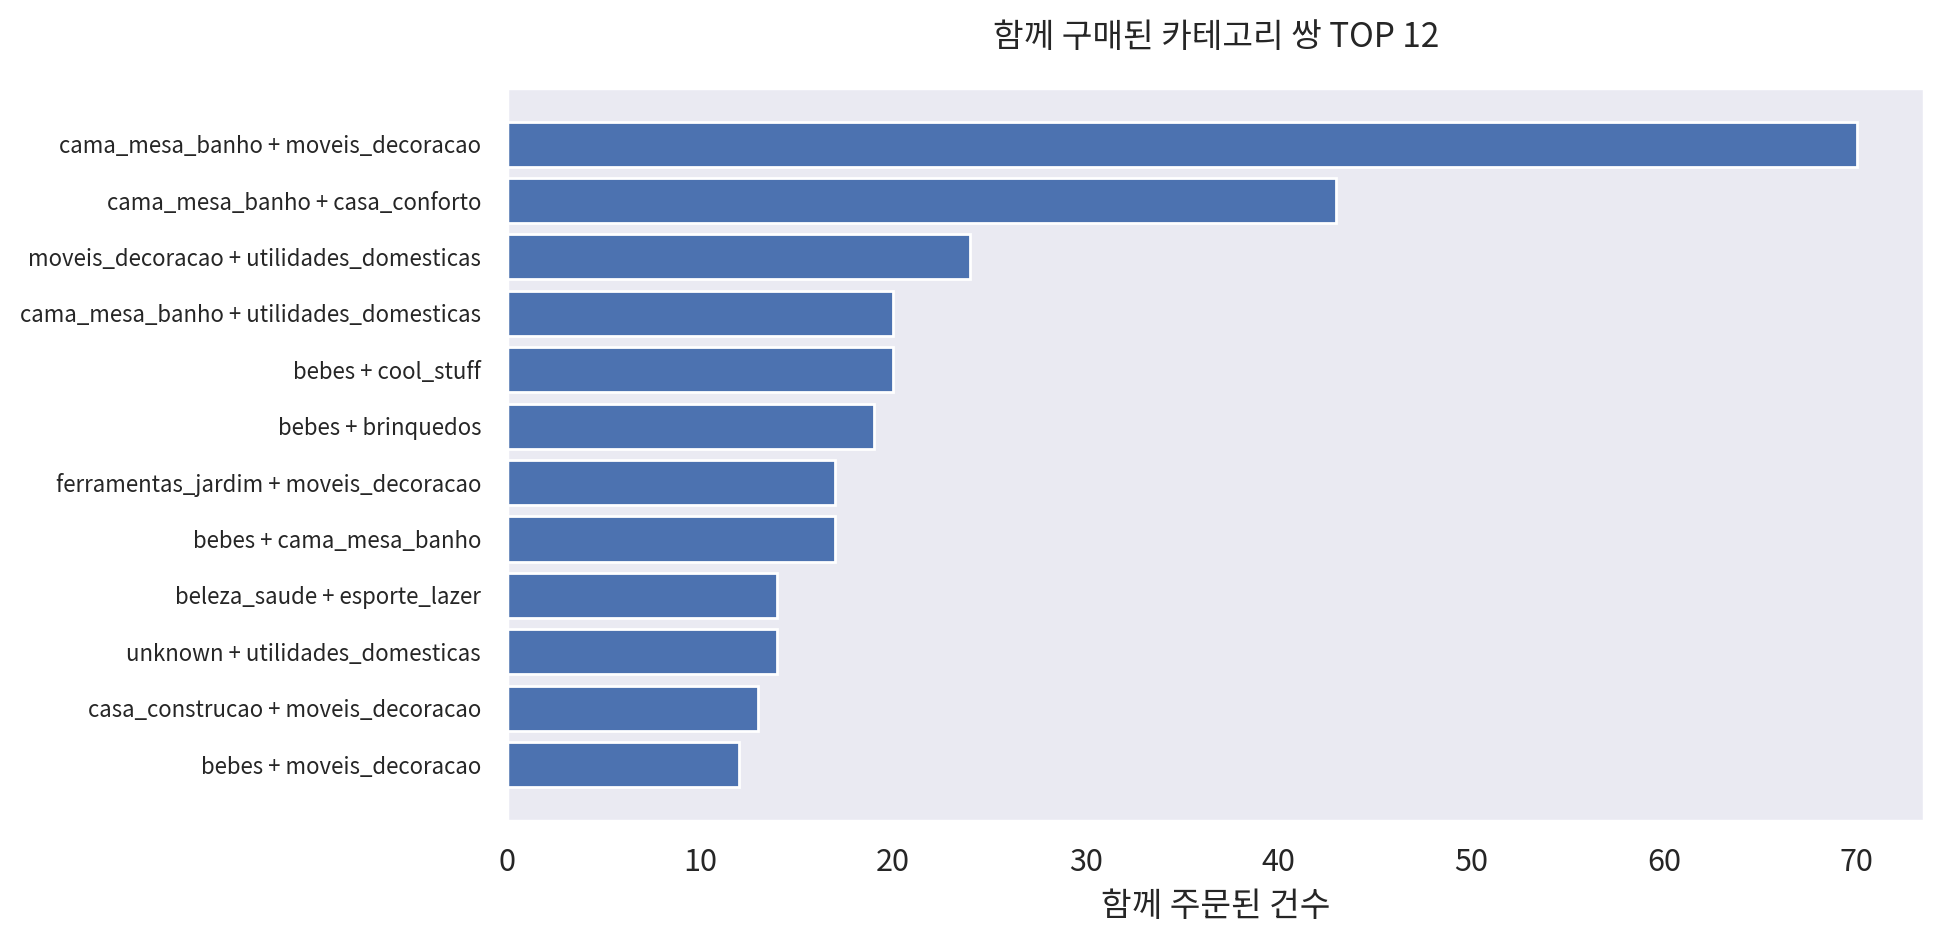

In [4]:
import matplotlib.pyplot as plt

top_pairs = pair_df.head(12)
top_pairs["pair"] = top_pairs["cat_a"] + " + " + top_pairs["cat_b"]
plt.figure(figsize=(10, 5))
plt.barh(range(len(top_pairs)), top_pairs["count"].values)
plt.yticks(range(len(top_pairs)), top_pairs["pair"].values, fontsize=8)
plt.xlabel("함께 주문된 건수")
plt.title("함께 구매된 카테고리 쌍 TOP 12")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()